<a href="https://colab.research.google.com/github/AdaYeager/YOLO/blob/main/%D0%BA%D0%BE%D0%BC%D0%BF_%D0%B7%D1%80%D0%B5%D0%BD%D0%B8%D0%B5_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Обучение модели YOLO для детекции карандашей и ручек

Обучить модель YOLO для детекции карандаша и ручки.
——————-
- Собрать данные (положить ручку 1-3 штуки на стол и карандаш 1-3 штуки), записать 2 видео по 30 секунд. Первое видео использовать для тренировки модели. Второе для проверки качества модели.
- Разметить данные (выбрать 60 фотографий для тренировки), разметить 2 класса ручка/карандаш. Размечать в любом из сервисов (Roboflow, Anylabel, Label-Studio, ...). Задача - детекция объектов. В трейн пойдут 50 фотографий, на валидацию 10 фотографий.
- Обучить модель YOLO (v8 или v11). Попробовать разные модели (n-nano, s-small). Обучать на видеокарте. Torch gpu установить.
- Оценить метрики. Какая модель лучше? Почему?
- Проверить модель на записанном втором видео. Либо, если есть вебкамера в компьютере/ноутбуке, то попробовать запустить модель в Real-Time.

1. Загрузка необходимых библиотек и подготовка окружения

In [4]:
# Устанавливаем PyTorch с поддержкой GPU (CUDA)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118


In [5]:
# Устанавливаем ultralytics (YOLO)
!pip install ultralytics

In [6]:
# Клонируем репозиторий YOLOv8
%cd /content/
!git clone https://github.com/ultralytics/ultralytics.git
%cd ultralytics

/content
fatal: destination path 'ultralytics' already exists and is not an empty directory.
/content/ultralytics


In [23]:
import os
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


2. Импорт данных и извлечение кадров из видео

In [8]:
VIDEO_PATH = '/content/gdrive/MyDrive/рк.mp4'
OUTPUT_DIR = 'frames/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [9]:
import cv2
cap = cv2.VideoCapture(VIDEO_PATH)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
print(f'Всего кадров: {frame_count}, FPS: {fps}')

for i in range(frame_count):
    ret, frame = cap.read()
    if not ret:
        break
    filename = f'{OUTPUT_DIR}/frame_{i}.jpg'
    cv2.imwrite(filename, frame)

cap.release()
cv2.destroyAllWindows()

Всего кадров: 925, FPS: 29.977314464729393


3. Разметка данных

makesense.ai

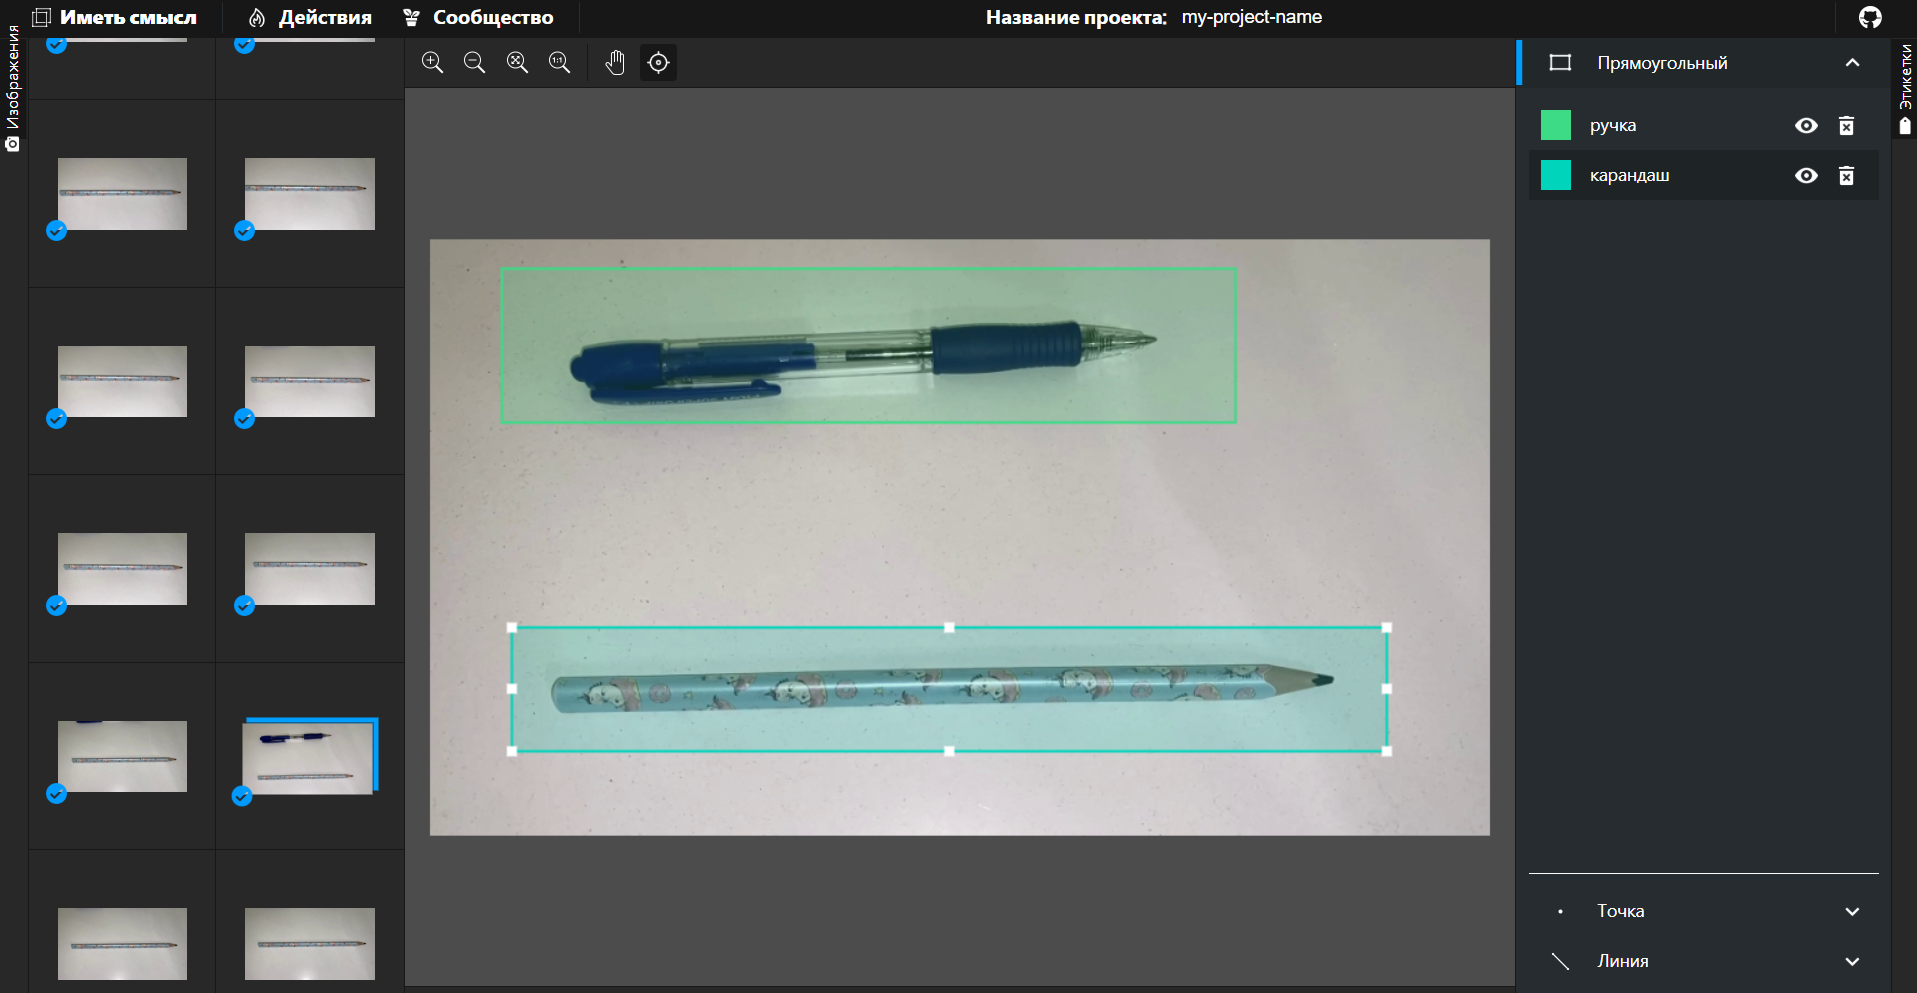

4. Создание структуры каталогов для YOLO

In [10]:
!mkdir /content/gdrive/MyDrive/dataset

!mkdir /content/gdrive/MyDrive/dataset/images
!mkdir /content/gdrive/MyDrive/dataset/images/test
!mkdir /content/gdrive/MyDrive/dataset/images/val

!mkdir /content/gdrive/MyDrive/dataset/labels
!mkdir /content/gdrive/MyDrive/dataset/labels/test
!mkdir /content/gdrive/MyDrive/dataset/labels/val


mkdir: cannot create directory ‘/content/gdrive/MyDrive/dataset’: File exists
mkdir: cannot create directory ‘/content/gdrive/MyDrive/dataset/images’: File exists
mkdir: cannot create directory ‘/content/gdrive/MyDrive/dataset/images/test’: File exists
mkdir: cannot create directory ‘/content/gdrive/MyDrive/dataset/images/val’: File exists
mkdir: cannot create directory ‘/content/gdrive/MyDrive/dataset/labels’: File exists
mkdir: cannot create directory ‘/content/gdrive/MyDrive/dataset/labels/test’: File exists
mkdir: cannot create directory ‘/content/gdrive/MyDrive/dataset/labels/val’: File exists


5. Обучение модели YOLO

In [11]:
%%writefile custom.yaml
train: /content/gdrive/MyDrive/dataset/images/test
val: /content/gdrive/MyDrive/dataset/images/val
nc: 2
names: ['pencil', 'pen']


Writing custom.yaml


In [12]:
from ultralytics import YOLO

model_nano = YOLO('yolov8n.pt') # Nano версия
results_nano = model_nano.train(data='custom.yaml', epochs=50, imgsz=640, device="cuda")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=custom.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line

In [13]:
model_small = YOLO('yolov8s.pt') # Small версия
results_small = model_small.train(data='custom.yaml', epochs=50, imgsz=640, device="cuda")

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=custom.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=Tru

6. Оценка метрик моделей

In [14]:
metrics_nano = results_nano.mean_results()

print("Nano Model Metrics:")
print(f"Precision: {metrics_nano[0]:.4f}")    # Точность
print(f"Recall: {metrics_nano[1]:.4f}")       # Полнота
print(f"mAP@0.5: {metrics_nano[2]:.4f}")      # Средняя точность
print(f"mAP@0.5-0.95: {metrics_nano[3]:.4f}") # Средняя точность

Nano Model Metrics:
Precision: 0.7047
Recall: 0.6667
mAP@0.5: 0.6913
mAP@0.5-0.95: 0.5216


In [15]:
metrics_small = results_small.mean_results()

print("Small Model Metrics:")
print(f"Precision: {metrics_small[0]:.4f}")    # Точность
print(f"Recall: {metrics_small[1]:.4f}")       # Полнота
print(f"mAP@0.5: {metrics_small[2]:.4f}")      # Средняя точность
print(f"mAP@0.5-0.95: {metrics_small[3]:.4f}") # Средняя точность

Small Model Metrics:
Precision: 0.8103
Recall: 1.0000
mAP@0.5: 0.9125
mAP@0.5-0.95: 0.6101


In [16]:
# Проверяем содержимое
summaries = results_small.summary()

# Выведем сырой результат
print(summaries)

[{'Class': 'pencil', 'Images': np.int64(7), 'Instances': np.int64(7), 'Box-P': np.float64(0.89816), 'Box-R': np.float64(1.0), 'Box-F1': np.float64(0.94635), 'mAP50': np.float64(0.995), 'mAP50-95': np.float64(0.75596)}, {'Class': 'pen', 'Images': np.int64(3), 'Instances': np.int64(3), 'Box-P': np.float64(0.72251), 'Box-R': np.float64(1.0), 'Box-F1': np.float64(0.8389), 'mAP50': np.float64(0.83), 'mAP50-95': np.float64(0.46429)}]


In [17]:
# Проверяем содержимое
summaries = results_nano.summary()

# Выведем сырой результат
print(summaries)

[{'Class': 'pencil', 'Images': np.int64(7), 'Instances': np.int64(7), 'Box-P': np.float64(0.96569), 'Box-R': np.float64(1.0), 'Box-F1': np.float64(0.98255), 'mAP50': np.float64(0.995), 'mAP50-95': np.float64(0.81129)}, {'Class': 'pen', 'Images': np.int64(3), 'Instances': np.int64(3), 'Box-P': np.float64(0.44368), 'Box-R': np.float64(0.33333), 'Box-F1': np.float64(0.38067), 'mAP50': np.float64(0.3875), 'mAP50-95': np.float64(0.23197)}]


7. Проверка лучшей модели


0: 480x640 1 pencil, 13.9ms
Speed: 2.2ms preprocess, 13.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


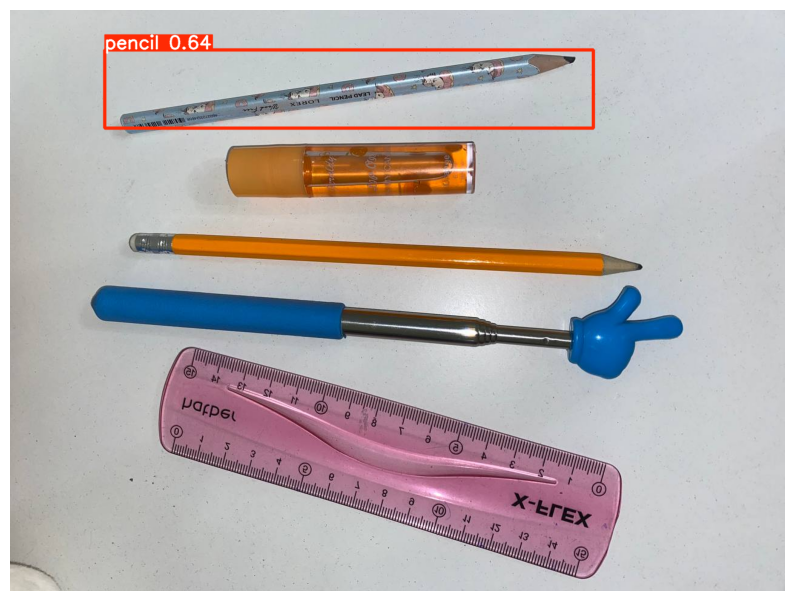


0: 480x640 1 pencil, 13.0ms
Speed: 2.7ms preprocess, 13.0ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


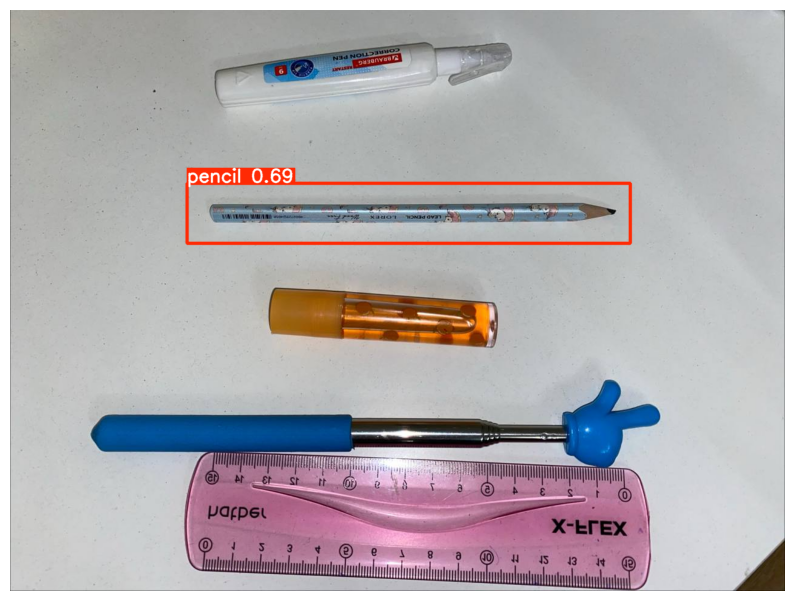


0: 480x640 1 pen, 13.0ms
Speed: 2.6ms preprocess, 13.0ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


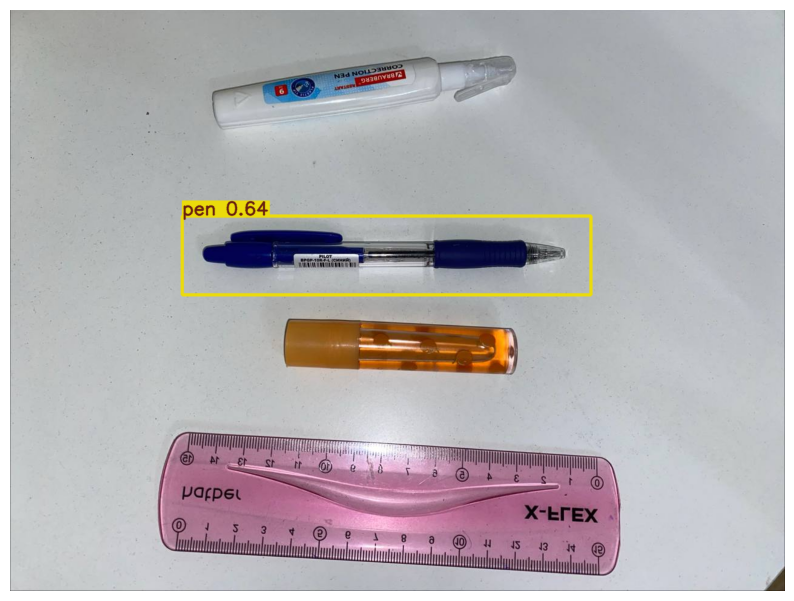

In [26]:
import matplotlib.pyplot as plt
import cv2

model = YOLO('/content/ultralytics/runs/detect/train2/weights/best.pt')

photos_dir = '/content/gdrive/MyDrive/проверка'

# Прогоняем модель на каждом изображении
for img_file in sorted(os.listdir(photos_dir)):
    if img_file.endswith(".jpg"):
        img_path = os.path.join(photos_dir, img_file)
        img = cv2.imread(img_path)

        # Преобразуем изображение в RGB (для подачи в модель)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        results = model.predict(img_rgb, conf=0.61)

        # Первый результат из списка
        result = results[0]

        # Обратно конвертируем изображение в BGR для правильного отображения
        plot_img_bgr = cv2.cvtColor(result.plot(), cv2.COLOR_RGB2BGR)

        # Отображение результатов
        plt.figure(figsize=(10, 10))
        plt.axis('off')
        plt.imshow(plot_img_bgr[:, :, ::-1])  # [::-1] переворачивает каналы RGB -> BGR
        plt.show()
